In [3]:
%pip install torch torchvision matplotlib scikit-learn numpy

   ---------------------------------------- 0.0/110.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/110.9 MB 10.4 MB/s eta 0:00:11
   - -------------------------------------- 2.9/110.9 MB 7.9 MB/s eta 0:00:14
   - -------------------------------------- 5.0/110.9 MB 9.0 MB/s eta 0:00:12
   -- ------------------------------------- 6.3/110.9 MB 9.1 MB/s eta 0:00:12
   --- ------------------------------------ 8.4/110.9 MB 8.8 MB/s eta 0:00:12
   --- ------------------------------------ 10.5/110.9 MB 9.0 MB/s eta 0:00:12
   ---- ----------------------------------- 12.6/110.9 MB 9.2 MB/s eta 0:00:11
   ----- ---------------------------------- 14.7/110.9 MB 9.3 MB/s eta 0:00:11
   ----- ---------------------------------- 16.0/110.9 MB 9.2 MB/s eta 0:00:11
   ------ --------------------------------- 17.6/110.9 MB 9.0 MB/s eta 0:00:11
   ------- -------------------------------- 19.9/110.9 MB 9.0 MB/s eta 0:00:11
   ------- -------------------------------- 21.8/110.9 MB 9.1 MB

Using device: cpu
--- Training Baseline MLP (SGD) ---
Epoch 1/15 | Loss: 0.5814 | Val Loss: 0.4795 | Acc: 0.7918
Epoch 2/15 | Loss: 0.3966 | Val Loss: 0.4102 | Acc: 0.8549
Epoch 3/15 | Loss: 0.3564 | Val Loss: 0.3907 | Acc: 0.8686
Epoch 4/15 | Loss: 0.3307 | Val Loss: 0.3750 | Acc: 0.8791
Epoch 5/15 | Loss: 0.3114 | Val Loss: 0.3627 | Acc: 0.8850
Epoch 6/15 | Loss: 0.2960 | Val Loss: 0.3512 | Acc: 0.8906
Epoch 7/15 | Loss: 0.2854 | Val Loss: 0.3607 | Acc: 0.8951
Epoch 8/15 | Loss: 0.2727 | Val Loss: 0.3462 | Acc: 0.8977
Epoch 9/15 | Loss: 0.2632 | Val Loss: 0.3553 | Acc: 0.9020
Epoch 10/15 | Loss: 0.2516 | Val Loss: 0.3380 | Acc: 0.9058
Epoch 11/15 | Loss: 0.2447 | Val Loss: 0.3460 | Acc: 0.9089
Epoch 12/15 | Loss: 0.2352 | Val Loss: 0.3592 | Acc: 0.9119
Epoch 13/15 | Loss: 0.2292 | Val Loss: 0.3575 | Acc: 0.9144
Epoch 14/15 | Loss: 0.2229 | Val Loss: 0.3408 | Acc: 0.9173
Epoch 15/15 | Loss: 0.2140 | Val Loss: 0.3502 | Acc: 0.9194
Training completed in 313.74 seconds.

--- Training Ove

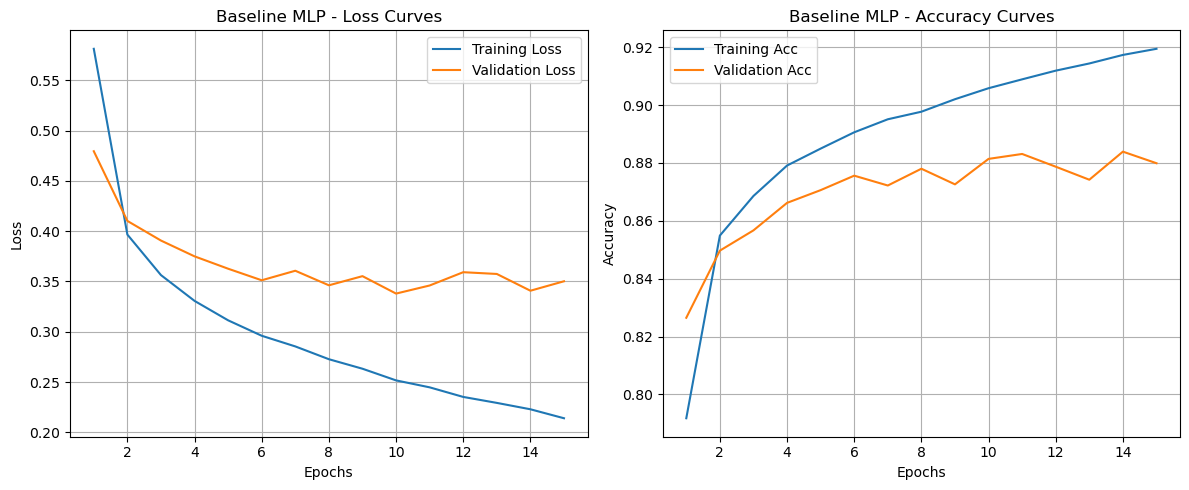

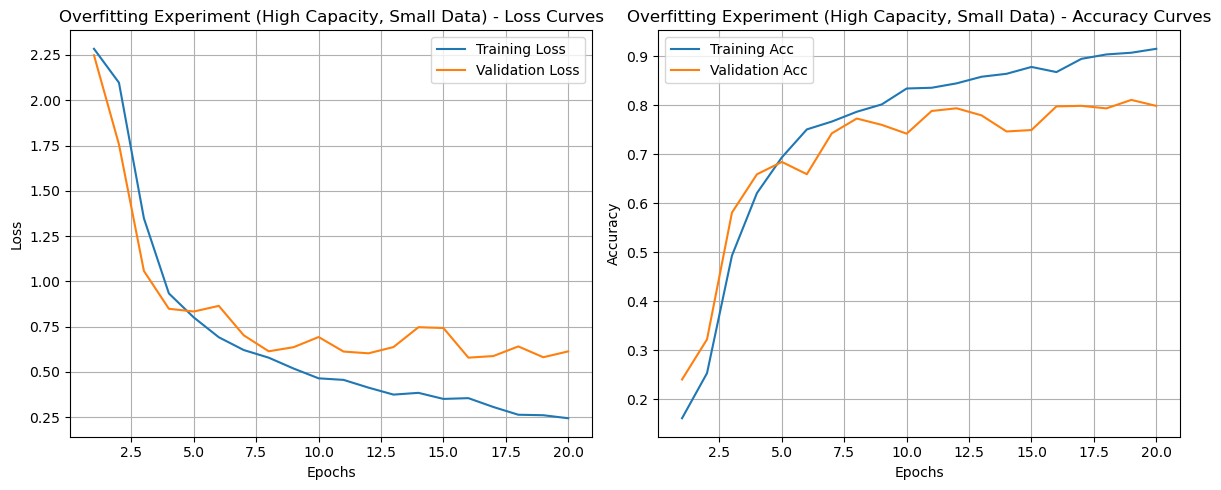

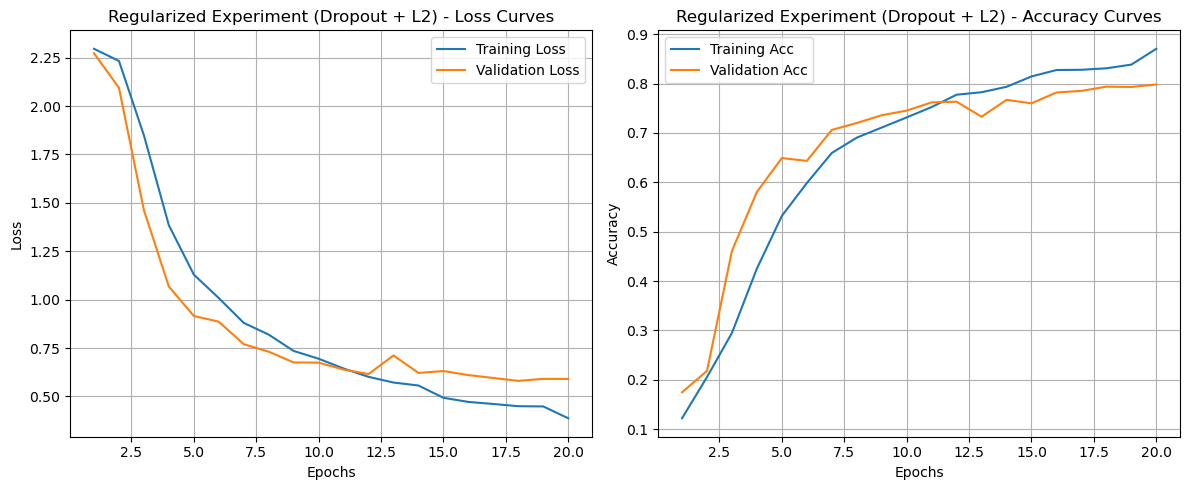

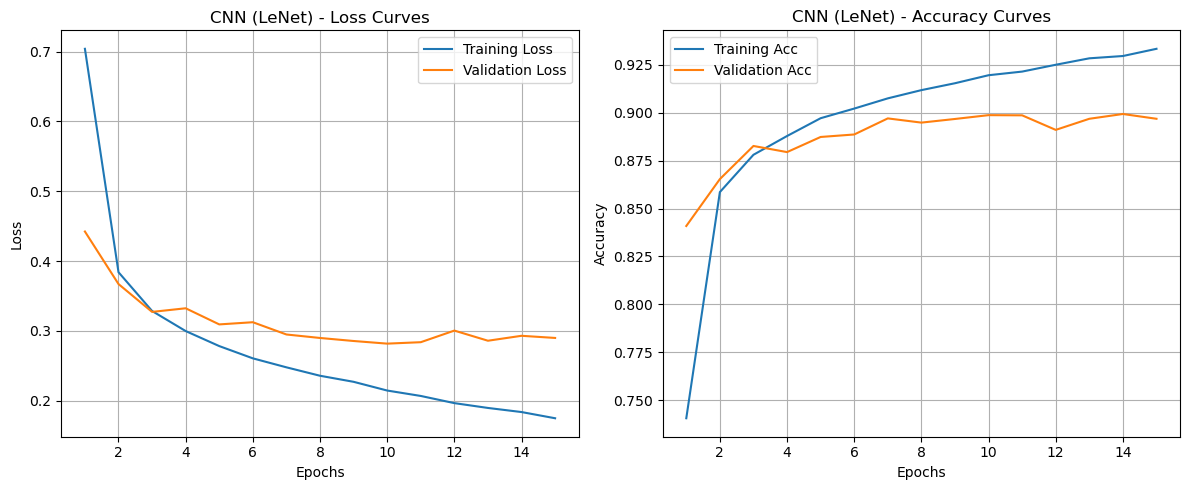

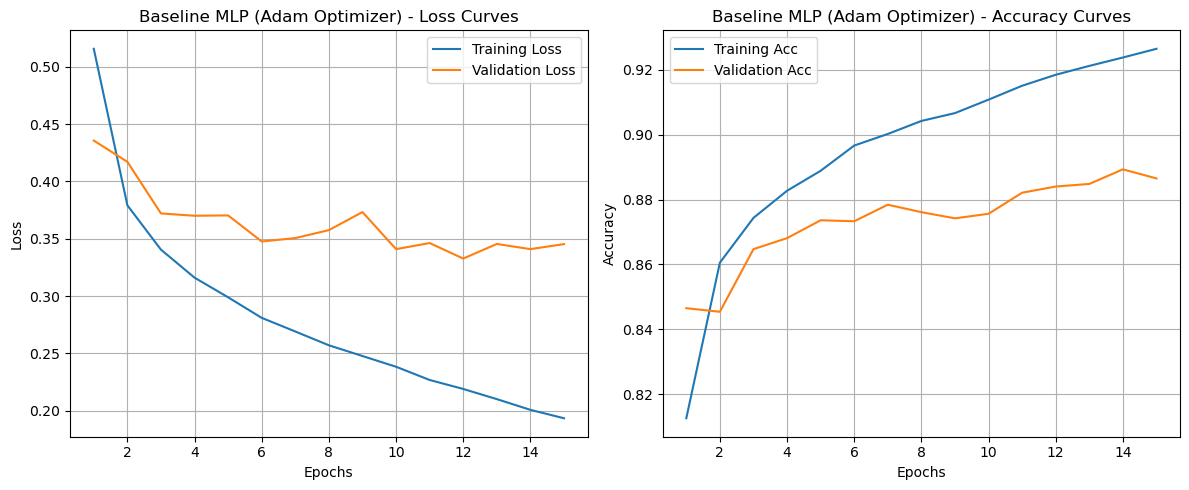

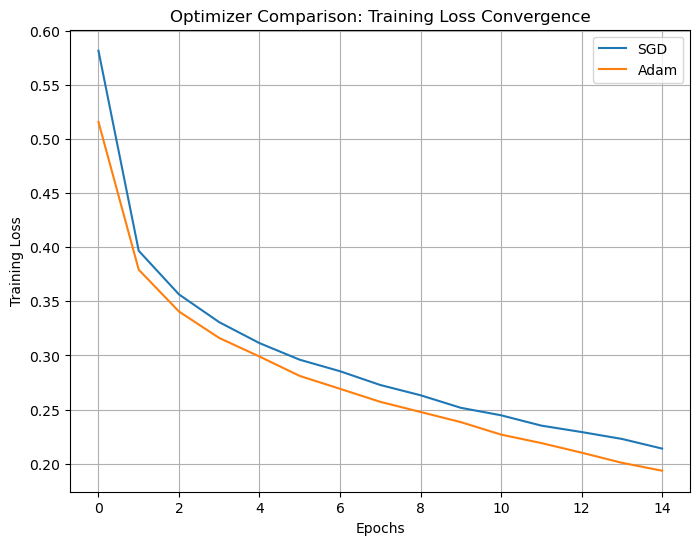

Generating Confusion Matrix for CNN...


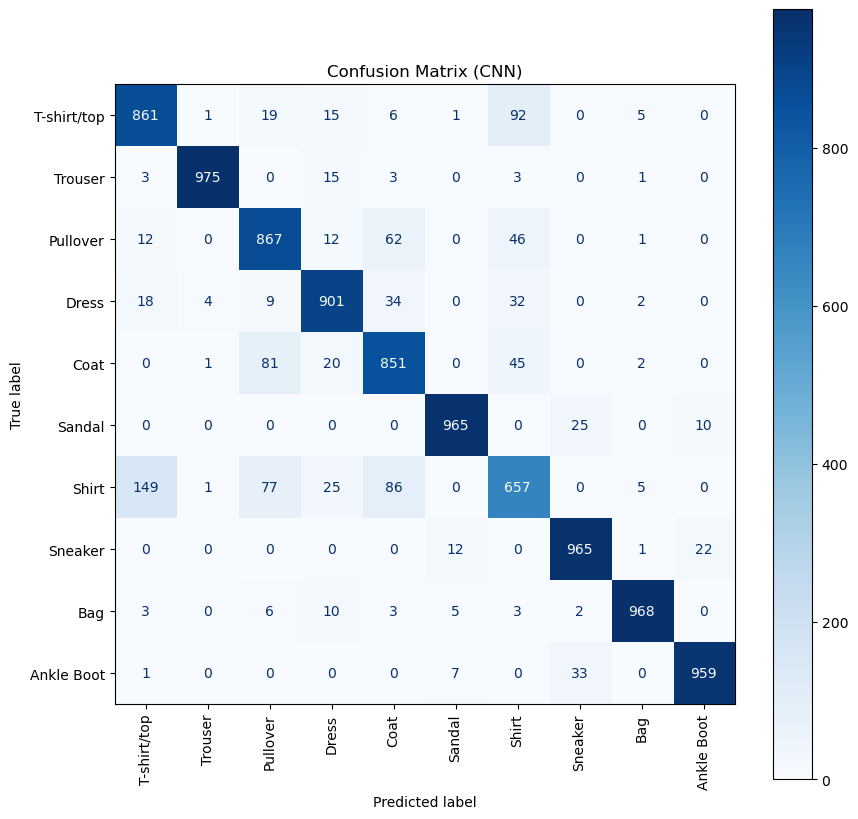

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time

# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# SECTION 1: DATA PREPARATION
# ==========================================

# Transform: Convert images to tensor and normalize (standard practice)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load Fashion-MNIST Dataset
print("Downloading Fashion-MNIST...")
full_train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create standard DataLoaders
train_loader = DataLoader(full_train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

# Create a "Small Subset" for Part 2 (Overfitting Experiment)
# We take only the first 2000 images to force overfitting easily using PyTorch "Subset" class
subset_indices = range(2000)
small_train_set = Subset(full_train_set, subset_indices)
small_train_loader = DataLoader(small_train_set, batch_size=64, shuffle=True)


#this is the 10 classes for prediction
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# ==========================================
# SECTION 2: MODEL ARCHITECTURES
# ==========================================

# --- Part 1 Model: Baseline MLP ---
class BaselineMLP(nn.Module):
    def __init__(self):
        super(BaselineMLP, self).__init__()
        
        #------------  What you need to do below, No. 1 ----------------------------
        
         # "unrolls" the image row by row into a single long line of pixels. This is NOT convolution.
        # flattens layer to convert 1x28x28 to a 784 vector
        self.flatten = nn.Flatten()
        # Architecture requirements:
        # - Input flattened to 784
        #  hidden1: 128 neurons+ Relu
        # Hidden 2: 64 neurons +Relu
        #  Output: 10 neurons 
        self.layers = nn.Sequential(
             nn.Linear(28 *28, 128),  # Linear from 784 to 128
            nn.ReLU(inplace=True),    # ReLU activation
            nn.Linear(128, 64),
            # Linear from 128 to 64
            nn.ReLU(inplace=True),    # RelU activation
            nn.Linear(64, 10)         # Output layer 64 to 10 
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

# --- Part 2 Model: Large Capacity MLP (for Overfitting) ---
class LargeMLP(nn.Module):
    def __init__(self, use_dropout=False): # use_dropout=False means the model creates a pure, massive network to force overfitting (memorizing the data)
        super(LargeMLP, self).__init__()

        self.flatten = nn.Flatten()
        #------------  What you need to do below, No. 2 ----------------------------

        # "unrolls" the image row by row into a single long line of pixels. This is NOT convolution.
        in_features = 28 * 28
        hidden_units = 512
        num_hidden = 4
        # A very deep/wide network to memorize data we use a list of layers to defining layers, instead of defining layer one by one as we did for the Part 1 model.
        layers = [ ]
        # Input to first hidden
        layers.append(nn.Linear(in_features, hidden_units))
        layers.append(nn.ReLU(inplace=True))
        
        # subsequent hidden layers
        for _ in range(num_hidden - 1):
            layers.append(nn.Linear(hidden_units, hidden_units))
            layers.append(nn.ReLU(inplace=True))
            # Insert dropout after each hidden block if requested
            if use_dropout:
                layers.append(nn.Dropout(0.5))
        
        # Final output layer to 10 classes 
        layers.append(nn.Linear(hidden_units, 10))
            
        self.layers = nn.Sequential(*layers) #nn.Sequential glues all those layers together into a single block that executes them in order.

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x) #The vector is pushed through the sequential block (Linear -> ReLU -> Linear...), producing the final prediction.

# --- Part 3 Model: LeNet-Style CNN ---
# Based on LeNet architecture 
class LeNetCNN(nn.Module):
    def __init__(self):
        super(LeNetCNN, self).__init__()
        # features: conv to  relu to pool to conv to relu to pool
        # Followed by classifier flatten to FClayers to output
        self.features = nn.Sequential(
            
            #------------  What you need to do below, No. 3 ----------------------------
            # Implemented # 3 
            # Conv Layer1: in_channels=1  out_channels=6, kernel_size=5x5, padding=2, stride=1
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            # Maxpool 2x2, stride=2
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv layer2 after first pool, in_channels=6, out_channels=16, kernel_size=5x5, stride=1, padding=0
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),
            nn.ReLU(inplace=True),
            # MaxPool 2x2
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # after convolusion, we get the feature map, a two-dimension feature matrix 
        # For FashionMNIST 28x28:
        # conv1: padding=2,k=5 -> output size = 28 -> pool -> 14
        # conv2: k=5,pad=0 -> 14 - 5 + 1 = 10 -> pool -> 5
        # final feature map is (16 channels, 5, 5) => 16*5*5 = 400 features
        # The following is to construct a neural network with two hidder layers adn one output layer, we use ReLU for activation function between layers
        #, think about the input and output dimension, which are teh first and second argument
        flattened_size = 16 * 5 * 5
        self.classifier = nn.Sequential(

             #------------  What you need to do below, No. 4 ----------------------------
            nn.Flatten(),                  # convert (batch,16,5,5) to a (batch,400)
            nn.Linear(flattened_size, 120),# FC: 400 -> 120
            nn.ReLU(inplace=True),
            nn.Linear(120, 84),            # FC: 120 -> 84
            nn.ReLU(inplace=True),
            nn.Linear(84, 10)              # Final logits: 84 -> 10
         
        )

    def forward(self, x):
        # x shape: (batch, 1, 28, 28)
        x = self.features(x)
        x = self.classifier(x)
        return x

# ==========================================
# SECTION 3: TRAINING ENGINE
# ==========================================

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=20, name="Model"):
    print(f"--- Training {name} ---")
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    model.to(device)
    
    start_time = time.time()

    for epoch in range(epochs):
        # Training Phase
        model.train() # Set to training mode (enables Dropout)
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()       # Zero gradients
            outputs = model(inputs)     # Forward pass 
            loss = criterion(outputs, labels) # Compute loss 
            loss.backward()             # Backpropagation 
            optimizer.step()            # Update weights 
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        # Validation Phase
        model.eval() # Set to eval mode (disables Dropout)
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = correct_val / total_val
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Acc: {epoch_train_acc:.4f}")

    duration = time.time() - start_time
    print(f"Training completed in {duration:.2f} seconds.\n")
    return history

# ==========================================
# SECTION 4: EXECUTION (PARTS 1-3)
# ==========================================

# Define Loss Function (Cross Entropy for classification )
criterion = nn.CrossEntropyLoss()

# --- PART 1: Baseline MLP ---
mlp_model = BaselineMLP()
optimizer_sgd = optim.SGD(mlp_model.parameters(), lr=0.01, momentum=0.9) 
history_mlp = train_model(mlp_model, train_loader, test_loader, optimizer_sgd, criterion, epochs=15, name="Baseline MLP (SGD)")

# --- PART 2A: Overfitting (Large Model, Small Data) ---
overfit_model = LargeMLP(use_dropout=False)
optimizer_overfit = optim.SGD(overfit_model.parameters(), lr=0.01, momentum=0.9)
history_overfit = train_model(overfit_model, small_train_loader, test_loader, optimizer_overfit, criterion, epochs=20, name="Overfit MLP (No Reg)")

# --- PART 2B: Regularization (Large Model, Small Data + Dropout + L2) ---
reg_model = LargeMLP(use_dropout=True) # Enable Dropout layers
# Weight Decay = L2 Regularization 
optimizer_reg = optim.SGD(reg_model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4) 
history_reg = train_model(reg_model, small_train_loader, test_loader, optimizer_reg, criterion, epochs=20, name="Regularized MLP")

# --- PART 3: CNN (LeNet) ---
cnn_model = LeNetCNN()
optimizer_cnn = optim.SGD(cnn_model.parameters(), lr=0.01, momentum=0.9)
history_cnn = train_model(cnn_model, train_loader, test_loader, optimizer_cnn, criterion, epochs=15, name="LeNet CNN")

# --- Optimization Comparison (Baseline with Adam) ---
adam_model = BaselineMLP()
optimizer_adam = optim.Adam(adam_model.parameters(), lr=0.001) #
history_adam = train_model(adam_model, train_loader, test_loader, optimizer_adam, criterion, epochs=15, name="Baseline MLP (Adam)")

# ==========================================
# SECTION 5: VISUALIZATION & ANALYSIS
# ==========================================

def plot_curves(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Training Acc')
    plt.plot(epochs, history['val_acc'], label='Validation Acc')
    plt.title(f'{title} - Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# 1. Plot Training Curves
plot_curves(history_mlp, "Baseline MLP")
plot_curves(history_overfit, "Overfitting Experiment (High Capacity, Small Data)")
plot_curves(history_reg, "Regularized Experiment (Dropout + L2)")
plot_curves(history_cnn, "CNN (LeNet)")
plot_curves(history_adam, "Baseline MLP (Adam Optimizer)")

# 2. Optimization Comparison Plot (Zooming in on convergence)
plt.figure(figsize=(8, 6))
plt.plot(history_mlp['train_loss'], label='SGD')
plt.plot(history_adam['train_loss'], label='Adam')
plt.title("Optimizer Comparison: Training Loss Convergence")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.legend()
plt.grid()
plt.show()

# 3. Confusion Matrix (Using the CNN model)
print("Generating Confusion Matrix for CNN...")
cnn_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = cnn_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix (CNN)")
plt.show()